# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:


**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person's work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## scikit-learn, for building the models later
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder

print('All libraries imported successfully.')

All libraries imported successfully.


# 1. Business Understanding

goal: in singapore, anyone who wants to register a new car first needs to buy a COE (certificate of entitlement). the price of the COE is called the premium, and it is decided by a bidding exercise that happens twice a month. the premium is only announced after the bidding closes. this is a problem for used car dealers and platforms like sgcarmart and carro, because they often need to give a customer a price before the result comes out. if they guess the premium too low they lose profit on the deal, and if they guess too high they lose the sale to a competitor.

the business goal of this project is to build a regression model that predicts the COE premium using the info that is already visible during the bidding round, like the quota released for that category, the number of bids received (which shows demand), the vehicle class and the date. by estimating the premium early, a dealer can price their cars more accurately, protect their margins and lower the risk of over or under quoting. since the premium is a continuous dollar value, this is a supervised regression task, and i will measure success by how close the predictions are to the actual premiums (in dollars).

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## read the .csv file into a pandas dataframe
FILE_PATH = 'COEBiddingResultsPrices.csv'
df = pd.read_csv(FILE_PATH)

## show the first 10 rows to check the data loaded correctly
df.head(10)

,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,2010-01,1,Category A,1152,1145,1342,18502
1,2010-01,1,Category B,687,679,883,19190
2,2010-01,1,Category C,173,173,265,19001
3,2010-01,1,Category D,373,365,509,889
4,2010-01,1,Category E,586,567,1011,19889
5,2010-01,2,Category A,1151,1149,1673,20501
6,2010-01,2,Category B,717,717,1105,22400
7,2010-01,2,Category C,181,173,280,20090
8,2010-01,2,Category D,378,378,551,852
9,2010-01,2,Category E,588,579,1322,21899


## 2.2 Summary Statistics

In [3]:
## check the data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1925 entries, 0 to 1924
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   month          1925 non-null   object
 1   bidding_no     1925 non-null   int64 
 2   vehicle_class  1925 non-null   object
 3   quota          1925 non-null   int64 
 4   bids_success   1925 non-null   object
 5   bids_received  1925 non-null   object
 6   premium        1925 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 105.4+ KB


the dataset has 1925 rows and 7 columns. month and vehicle_class are text (object) columns, while bidding_no, quota and premium are integers. i also notice that bids_success and bids_received came in as object (text) instead of numbers. this is because the bigger values in the csv are written with commas, like "1,203". so i will need to clean these two columns and turn them into numbers later in data preparation.

In [4]:
## check for missing data
df.isnull().sum()

month            0
bidding_no       0
vehicle_class    0
quota            0
bids_success     0
bids_received    0
premium          0
dtype: int64

there are no missing values in any column, so i don't need to drop or fill in any data. this keeps the cleaning simple, the main job is just fixing the two text columns that should be numbers.

In [5]:
## look at the summary statistics
df.describe()

,bidding_no,quota,premium
count,1925.000000,1925.000000,1925.000000
mean,1.498701,568.930390,52263.044156
std,0.500128,418.923677,33814.803606
min,1.000000,43.000000,852.000000
25%,1.000000,289.000000,29501.000000
50%,1.000000,445.000000,49996.000000
75%,2.000000,677.000000,74801.000000
max,2.000000,2272.000000,158004.000000


the premium (my target) goes from about \$852 up to \$158,004, with an average of around \$52,000 and a big standard deviation of about \$33,800. this huge spread tells me the premium is very different across categories, category D (motorcycles) is cheap while the car categories are expensive. because the target varies so much, vehicle_class is probably going to be a very important feature.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

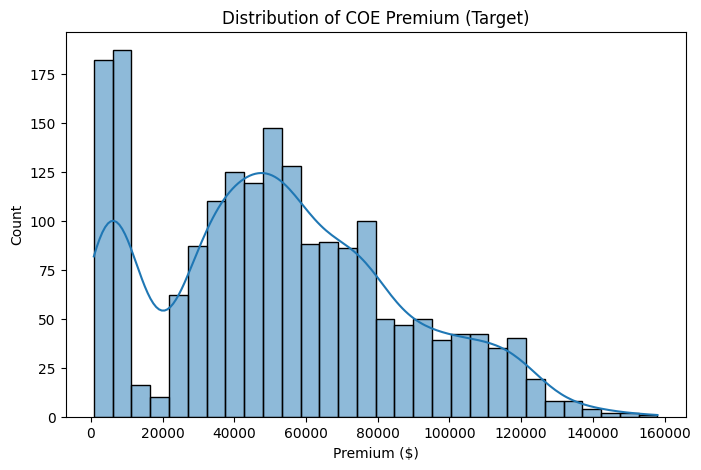

In [6]:
## look at the distribution of the target (premium)
plt.figure(figsize=(8, 5))
sns.histplot(df['premium'], bins=30, kde=True)
plt.title('Distribution of COE Premium (Target)')
plt.xlabel('Premium ($)')
plt.ylabel('Count')
plt.show()

the premium is not a single normal bell curve, it looks spread out with more than one peak. there is a clear group of very low premiums near \$0 to \$15,000 (these are the category D motorcycle rounds) and then a wider group of high premiums between \$40,000 and \$150,000 (the car categories). because the target has these separate groups driven by vehicle_class, a single straight line model (linear regression) might struggle to fit all of them at once. a tree based model like random forest can split the data by category first, so it will probably do better. i'll train both and compare.

### 2.3.1.2 Understanding distribution of features

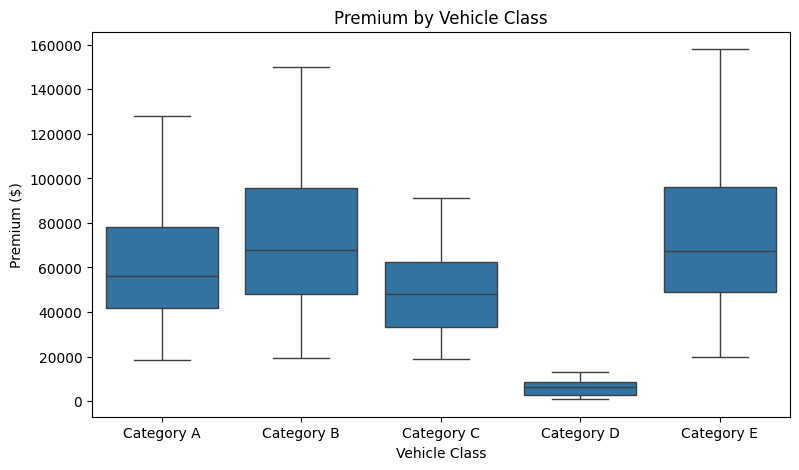

In [7]:
## look at the distribution of the features
## boxplot of premium for each vehicle class
plt.figure(figsize=(9, 5))
sns.boxplot(x='vehicle_class', y='premium', data=df)
plt.title('Premium by Vehicle Class')
plt.xlabel('Vehicle Class')
plt.ylabel('Premium ($)')
plt.show()

this boxplot clearly shows that vehicle class is the biggest driver of premium. category D (motorcycles) sits right at the bottom with only a few thousand dollars, while categories A, B, C and E are all much higher, with B and E reaching the highest values (above \$150,000). each box is also quite tall, which means premiums move up and down a lot within each category over the years. there are a few outlier points but they look like real market highs, not data entry mistakes. so vehicle_class must be included and one hot encoded so the model can learn the big price gap between motorcycles and cars.

### 2.3.2 Understanding relationship between variables

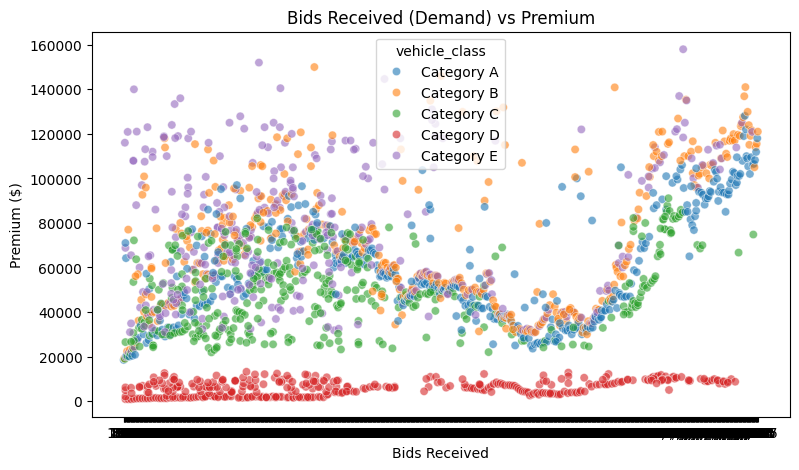

In [8]:
## look at the relationship between variables
## scatterplot of demand (bids_received) vs premium, coloured by vehicle class
plt.figure(figsize=(9, 5))
sns.scatterplot(x='bids_received', y='premium', hue='vehicle_class', data=df, alpha=0.6)
plt.title('Bids Received (Demand) vs Premium')
plt.xlabel('Bids Received')
plt.ylabel('Premium ($)')
plt.show()

within each category (colour), rounds with more bids received tend to sit at higher premiums, which matches the idea that stronger demand pushes the price up. but it is not one clean line across the whole chart, because each category lives in its own price band, a high number of bids in category D still gives a low premium. so demand matters, but only compared to the quota for that category. this is why i will create an oversubscription ratio (bids_received / quota) in data preparation, which should capture demand pressure better than the raw bid count.

# 3. Data Preparation

## 3.1 Data Cleaning

in this section i get the data ready for modelling. there are a few things to do:
1. turn bids_success and bids_received from text (with commas) into numbers.
2. feature engineering: get year and month_num out of the month column, and make a new oversubscription_ratio feature (bids_received / quota).
3. handle data leakage: drop bids_success, because the number of successful bids is only known after the bidding round closes, at the same time the premium is decided. if i used it that would be cheating (leakage), since a dealer wouldn't have it yet when they need the prediction. i also drop the original month text column after i pull out the useful parts.

In [9]:
## clean the data
## make a copy so the original df stays safe
data = df.copy()

## 1. turn the two text columns into numbers by removing the commas
data['bids_success'] = data['bids_success'].astype(str).str.replace(',', '').astype(int)
data['bids_received'] = data['bids_received'].astype(str).str.replace(',', '').astype(int)

## 2. feature engineering
## get the year and month number from the 'month' column (format is 'YYYY-MM')
data['year'] = data['month'].str.split('-').str[0].astype(int)
data['month_num'] = data['month'].str.split('-').str[1].astype(int)

## create the oversubscription ratio = demand / supply
## a higher ratio means many bidders fighting over few COEs, which pushes the premium up
data['oversubscription_ratio'] = data['bids_received'] / data['quota']

## 3. drop leakage / unused columns
## - 'bids_success' is only known after bidding closes (data leakage)
## - 'month' text is replaced by year + month_num
data = data.drop(columns=['bids_success', 'month'])

print('Shape after cleaning:', data.shape)
data.head()

Shape after cleaning: (1925, 8)


,bidding_no,vehicle_class,quota,bids_received,premium,year,month_num,oversubscription_ratio
0,1,Category A,1152,1342,18502,2010,1,1.164931
1,1,Category B,687,883,19190,2010,1,1.285298
2,1,Category C,173,265,19001,2010,1,1.531792
3,1,Category D,373,509,889,2010,1,1.364611
4,1,Category E,586,1011,19889,2010,1,1.725256


why did i make these features? the oversubscription_ratio takes two raw columns (demand and quota) and turns them into one clear "how hot is this round" number. a ratio of 2.0 means twice as many bids as COEs available, which usually means a higher premium. splitting month into year and month_num lets the model pick up the long term rise in COE prices (year) and any seasonal pattern (month), which it couldn't do from a text date. and dropping bids_success keeps the model honest, so it only uses info a dealer would actually have before the result comes out.

In [10]:
## one hot encode the 'vehicle_class' column
## drop_first=True avoids the dummy variable trap by dropping one category
data = pd.get_dummies(data, columns=['vehicle_class'], drop_first=True)

## turn any True/False dummy columns into 1/0 integers
data = data.astype({col: int for col in data.columns if data[col].dtype == bool})

print('Columns after one-hot encoding:')
print(list(data.columns))
data.head()

Columns after one-hot encoding:
['bidding_no', 'quota', 'bids_received', 'premium', 'year', 'month_num', 'oversubscription_ratio', 'vehicle_class_Category B', 'vehicle_class_Category C', 'vehicle_class_Category D', 'vehicle_class_Category E']


,bidding_no,quota,bids_received,premium,year,month_num,oversubscription_ratio,vehicle_class_Category B,vehicle_class_Category C,vehicle_class_Category D,vehicle_class_Category E
0,1,1152,1342,18502,2010,1,1.164931,0,0,0,0
1,1,687,883,19190,2010,1,1.285298,1,0,0,0
2,1,173,265,19001,2010,1,1.531792,0,1,0,0
3,1,373,509,889,2010,1,1.364611,0,0,1,0
4,1,586,1011,19889,2010,1,1.725256,0,0,0,1


## 3.2 Train-Test Split

In [11]:
## split the data into a train set and a test set
## X = all the input features, y = the target (premium)
X = data.drop(columns=['premium'])
y = data['premium']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', X_train.shape[0])
print('Testing rows: ', X_test.shape[0])
print('Number of features:', X_train.shape[1])

Training rows: 1540
Testing rows:  385
Number of features: 10


# 4. Modelling

i will train two different types of model so i can compare a simple baseline against a stronger method:
1. linear regression, a simple and easy to explain baseline that draws straight line relationships.
2. random forest regressor, a stronger tree based model that can capture the non-linear, category driven pattern i saw in the EDA.

### 4.2 Train Model

In [12]:
## set up and train the models
## model 1: linear regression (baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print('Linear Regression trained.')

## model 2: random forest regressor (advanced)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
print('Random Forest trained.')

Linear Regression trained.


Random Forest trained.
